# Test Pipeline: RA Cohort from MIMIC-IV

End-to-end test of the new preprocessing and MAP functions against a random
sample of MIMIC-IV data. Goal: verify that `build_obs_log` → `preprocess_map`
→ `run_map` produces a valid RA cohort.

**Pipeline:**
1. Load ONCE features for RA (PheCode 714.1)
2. Sample `SAMPLE_N` patients, load their diagnoses + admissions
3. Build ICD observation log via `icd_to_events`
4. Restrict to **candidate patients** — those with ≥1 ONCE-identified feature
5. Load discharge notes *only for candidates* (capped at `MAX_NOTES`) → NLP obs log
6. Assemble full observation log via `build_obs_log`
7. `preprocess_map` → mat_df, note_df
8. `run_map` → MAP scores + binary phenotype labels
9. Sanity checks throughout

**Speed:** Steps 2–6 are restricted to sampled/candidate patients so the notebook
runs in a few minutes. Set `INCLUDE_NLP = False` to skip MedSpaCy entirely.

In [37]:
import os
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
SAMPLE_N = 20000  # patients to sample from MIMIC-IV (set None to use all)
RANDOM_SEED = 42
INCLUDE_NLP = True  # set False to skip MedSpaCy (faster; codified features only)
MAX_NOTE_CHARS = (
    5_000  # truncate each note to this many chars before NLP (speed vs recall)
)
NOTES_PER_PATIENT = 3  # most recent discharge notes per patient for NLP (None = all)

MAIN_PHECODE = "714.1"  # RA anchor PheCode

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath(".")
PROJECT_DIR = os.path.abspath("..")
MIMIC_HOSP = os.path.join(PROJECT_DIR, "mimiciv", "hosp")
MIMIC_NOTE = os.path.join(PROJECT_DIR, "mimiciv", "note")

PHECODE_MAP = os.path.join(NOTEBOOK_DIR, "Phecode_map_v1_2_icd9_icd10cm.csv")
ONCE_CODIFIED = os.path.join(
    NOTEBOOK_DIR, "ONCE_Rheumatoid Arthritis_PheCode714.1_cos0.165.csv"
)
ONCE_NARRATIVE = os.path.join(
    NOTEBOOK_DIR,
    "ONCE_Rheumatoid Arthritis_C0003873_titlecos0.5_titlecut0.3_exactFALSE.csv",
)
NOTES_FILE = os.path.join(MIMIC_NOTE, "discharge.csv.gz")

# ── sys.path: add src/ so local modules import without install ─────────────────
for _p in [
    NOTEBOOK_DIR,
    os.path.join(NOTEBOOK_DIR, "map"),
    os.path.join(NOTEBOOK_DIR, "preprocessing"),
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── Verify paths ──────────────────────────────────────────────────────────────
for label, path in [
    ("MIMIC hosp", MIMIC_HOSP),
    ("PheCode map", PHECODE_MAP),
    ("ONCE codified", ONCE_CODIFIED),
    ("ONCE narrative", ONCE_NARRATIVE),
    ("Notes file", NOTES_FILE),
]:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {label}: {os.path.basename(path)}")

if INCLUDE_NLP and not os.path.exists(NOTES_FILE):
    print("\nWARNING: NOTES_FILE not found — setting INCLUDE_NLP = False")
    INCLUDE_NLP = False

  [OK] MIMIC hosp: hosp
  [OK] PheCode map: Phecode_map_v1_2_icd9_icd10cm.csv
  [OK] ONCE codified: ONCE_Rheumatoid Arthritis_PheCode714.1_cos0.165.csv
  [OK] ONCE narrative: ONCE_Rheumatoid Arthritis_C0003873_titlecos0.5_titlecut0.3_exactFALSE.csv
  [OK] Notes file: discharge.csv.gz


## 1. ONCE Features

`get_once_features()` reads the ONCE codified and narrative output files and
returns structured feature lists. `parse_once_by_modality()` then splits the
codified features by vocabulary so we can route each modality to the right
preprocessing function.

In [38]:
from once import get_once_features, parse_once_by_modality

once_features = get_once_features(ONCE_CODIFIED, ONCE_NARRATIVE)
by_modality = parse_once_by_modality(once_features)

print("=== ONCE codified features ===")
print(f"  Total in file              : {len(once_features['codified'])}")
print(f"  phenotyping_features=True  : {len(once_features['codified_list'])}")
for mod, codes in by_modality.items():
    if codes:
        print(f"    {mod:12s}: {len(codes)}  e.g. {codes[:3]}")

print("\n=== ONCE narrative (NLP) features ===")
print(f"  nlp_target_cuis  : {len(once_features['nlp_target_cuis'])}")

# Sanity: anchor PheCode must be in the codified list
anchor = f"PheCode:{MAIN_PHECODE}"
assert anchor in once_features["codified_list"], (
    f"Anchor '{anchor}' missing from ONCE codified_list — check ONCE file."
)
print(f"\n[OK] Anchor '{anchor}' found in codified_list.")

=== ONCE codified features ===
  Total in file              : 278
  phenotyping_features=True  : 41
    phecode     : 28  e.g. ['714.1', '714.2', '716.1']
    rxnorm      : 10  e.g. ['614391', '214555', '27169']
    shortname   : 3  e.g. ['CCP', 'ESR', 'MPV']

=== ONCE narrative (NLP) features ===
  nlp_target_cuis  : 442

[OK] Anchor 'PheCode:714.1' found in codified_list.


## 2. Sample Patients + Load Diagnoses and Admissions

We sample `SAMPLE_N` patients from the full patient list and filter all
subsequent table loads to that subset. This keeps runtimes short while
exercising all code paths.

Diagnoses are joined with admissions to attach `admittime` — `icd_to_events`
requires a date column to populate `datetime` in the observation log.

In [39]:
# Sample subject_ids
patients_df = pd.read_csv(
    os.path.join(MIMIC_HOSP, "patients.csv.gz"), usecols=["subject_id"]
)
if SAMPLE_N and SAMPLE_N < len(patients_df):
    sampled_ids = set(
        patients_df["subject_id"].sample(SAMPLE_N, random_state=RANDOM_SEED)
    )
    print(f"Sampled {SAMPLE_N:,} / {len(patients_df):,} patients (seed={RANDOM_SEED})")
else:
    sampled_ids = set(patients_df["subject_id"])
    print(f"Using all {len(sampled_ids):,} patients (no sampling)")

Sampled 20,000 / 364,627 patients (seed=42)


In [40]:
# Load admissions for the sampled patients
admissions_df = pd.read_csv(
    os.path.join(MIMIC_HOSP, "admissions.csv.gz"),
    usecols=["subject_id", "hadm_id", "admittime"],
    parse_dates=["admittime"],
)
admissions_df = admissions_df[admissions_df["subject_id"].isin(sampled_ids)]
print(
    f"admissions : {len(admissions_df):,} rows | {admissions_df['subject_id'].nunique():,} patients"
)

# Load diagnoses for the sampled patients
diagnoses_df = pd.read_csv(
    os.path.join(MIMIC_HOSP, "diagnoses_icd.csv.gz"),
    usecols=["subject_id", "hadm_id", "icd_code", "icd_version"],
    dtype={"icd_code": str},
)
diagnoses_df = diagnoses_df[diagnoses_df["subject_id"].isin(sampled_ids)]
print(
    f"diagnoses  : {len(diagnoses_df):,} rows | {diagnoses_df['subject_id'].nunique():,} patients"
)

# Join diagnoses with admissions to attach admittime
# icd_to_events requires a date column
diagnoses_with_dates = diagnoses_df.merge(
    admissions_df[["hadm_id", "admittime"]], on="hadm_id", how="left"
)
missing_dates = diagnoses_with_dates["admittime"].isna().sum()
print(
    f"Joined     : {len(diagnoses_with_dates):,} rows | {missing_dates:,} rows missing admittime"
)

# Sanity: check for expected RA patients in sample
ra_icd_codes = {"71410", "71411", "71412", "71419", "M0500", "M0510", "M0520", "M0530"}
ra_in_sample = diagnoses_df[diagnoses_df["icd_code"].isin(ra_icd_codes)][
    "subject_id"
].nunique()
print(f"\n[Sanity] Patients with raw RA ICD codes in sample: {ra_in_sample:,}")
print(
    "  (expect ~1.5% of sampled patients ≈",
    int(SAMPLE_N * 0.015),
    "if sampling is representative)",
)

admissions : 29,597 rows | 12,258 patients
diagnoses  : 340,696 rows | 12,250 patients
Joined     : 340,696 rows | 0 rows missing admittime

[Sanity] Patients with raw RA ICD codes in sample: 0
  (expect ~1.5% of sampled patients ≈ 300 if sampling is representative)


In [41]:
# ── Additional Step 2 sanity checks ─────────────────────────────────────────

# ICD version breakdown — expect a mix of ICD-9 and ICD-10 records
icd_ver_counts = diagnoses_df["icd_version"].value_counts().sort_index()
print("=== ICD version breakdown ===")
for ver, n in icd_ver_counts.items():
    print(f"  ICD-{ver}: {n:,} rows ({100 * n / len(diagnoses_df):.1f}%)")

# No duplicate (subject_id, hadm_id) pairs in admissions — each row is one admission
dup_adm = admissions_df.duplicated(subset=["subject_id", "hadm_id"]).sum()
assert dup_adm == 0, f"{dup_adm:,} duplicate (subject_id, hadm_id) rows in admissions"
print("\n[OK] No duplicate admissions.")

# Every sampled patient with diagnoses must have at least one admission
diag_pts = set(diagnoses_df["subject_id"])
adm_pts = set(admissions_df["subject_id"])
diag_only = diag_pts - adm_pts
print(f"\nPatients with diagnoses but no admission record: {len(diag_only):,}")
if diag_only:
    print(
        "  [WARN] These patients have no admittime — their diagnosis rows have null datetimes."
    )

# Admission coverage: what fraction of sampled patients have any admission?
pct_with_adm = 100 * len(adm_pts & sampled_ids) / len(sampled_ids)
print(f"Sampled patients with ≥1 admission: {pct_with_adm:.1f}%")
print("  (expect ~60–65% — not all MIMIC patients have inpatient stays)")

=== ICD version breakdown ===
  ICD-9: 156,698 rows (46.0%)
  ICD-10: 183,998 rows (54.0%)

[OK] No duplicate admissions.

Patients with diagnoses but no admission record: 0
Sampled patients with ≥1 admission: 61.3%
  (expect ~60–65% — not all MIMIC patients have inpatient stays)


## 3. Build ICD Observation Log

`icd_to_events` rolls up ICD-9/10 codes to PheCodes and returns rows in the
standard observation log schema: `(subject_id, event_type, event, value, datetime)`.
Rows with no PheCode mapping are silently dropped.

In [42]:
from preprocessing import icd_to_events

icd_obs = icd_to_events(
    diagnoses_with_dates,
    icd_col="icd_code",
    date_col="admittime",
    mapping_file=PHECODE_MAP,  # explicit path — avoids CWD dependency
)

print(
    f"ICD obs log : {len(icd_obs):,} rows | {icd_obs['subject_id'].nunique():,} patients"
)
print(
    f"Dropped     : {len(diagnoses_with_dates) - len(icd_obs):,} rows (no PheCode mapping)"
)

# Schema check
expected_cols = {"subject_id", "event_type", "event", "value", "datetime"}
assert expected_cols.issubset(icd_obs.columns), (
    f"Missing columns: {expected_cols - set(icd_obs.columns)}"
)
assert (icd_obs["event_type"] == "phecode").all(), (
    "event_type should be 'phecode' for all ICD rows"
)
assert icd_obs["event"].str.startswith("PheCode:").all(), (
    "event should be prefixed 'PheCode:'"
)
assert icd_obs["value"].isna().all(), "value should be None for ICD events"
print("\n[OK] Schema check passed.")

print(
    f"\nDate range  : {icd_obs['datetime'].min().date()} → {icd_obs['datetime'].max().date()}"
)
print(f"Unique PheCodes in sample: {icd_obs['event'].nunique()}")
print("\nSample rows:")
icd_obs.head(5)

ICD obs log : 318,330 rows | 12,240 patients
Dropped     : 22,366 rows (no PheCode mapping)

[OK] Schema check passed.

Date range  : 2110-01-12 → 2213-12-04
Unique PheCodes in sample: 1623

Sample rows:


,subject_id,event_type,event,value,datetime
0,10000690,phecode,PheCode:428.1,None,2150-09-16 19:48:00
1,10000690,phecode,PheCode:480,None,2150-09-16 19:48:00
2,10000690,phecode,PheCode:427.12,None,2150-09-16 19:48:00
3,10000690,phecode,PheCode:276.4,None,2150-09-16 19:48:00
4,10000690,phecode,PheCode:428.4,None,2150-09-16 19:48:00


## 4. Identify Candidate Cohort

Before loading notes (1.1 GB compressed), we identify which patients in the
sample have at least one ONCE-identified feature. These **candidate patients**
are the only ones MAP can phenotype — they form the study population.

Running NLP only on candidates (rather than all sampled patients) is the key
speed optimization: discharge notes for non-candidates carry no signal for MAP
and processing them wastes time.

In [43]:
# ── Additional Step 3 sanity checks ─────────────────────────────────────────

# Duplicate (subject_id, event, datetime) triplets are expected and valid:
# multiple ICD codes for the same admission can map to the same PheCode,
# producing identical rows. These are NOT a join fan-out problem — they reflect
# genuine PheCode collisions from the rollup. Flagged here for awareness only.
full_dups = icd_obs.duplicated().sum()
pct_dups = 100 * full_dups / len(icd_obs)
print(f"Fully duplicate obs rows: {full_dups:,} ({pct_dups:.1f}% of icd_obs)")
print("  (expected — multiple ICD codes on same admission can map to the same PheCode)")
print("  preprocess_map counts these as separate events, which is fine for MAP.")

# Top 10 PheCodes in the sample — confirms the rollup is producing sensible codes
print("\nTop 10 PheCodes by frequency:")
print(icd_obs["event"].value_counts().head(10).to_string())

# Date range sanity — MIMIC-IV uses shifted dates; all should be in [2100, 2220]
min_date = icd_obs["datetime"].min().year
max_date = icd_obs["datetime"].max().year
assert 2100 <= min_date <= 2220, f"Unexpected earliest date year: {min_date}"
assert 2100 <= max_date <= 2220, f"Unexpected latest date year: {max_date}"
print(
    f"\n[OK] Date range {min_date}–{max_date} within expected MIMIC-IV shifted range (2100–2220)."
)

Fully duplicate obs rows: 14,806 (4.7% of icd_obs)
  (expected — multiple ICD codes on same admission can map to the same PheCode)
  preprocess_map counts these as separate events, which is fine for MAP.

Top 10 PheCodes by frequency:
event
PheCode:401.1     10446
PheCode:411.4      8805
PheCode:272.1      8417
PheCode:318        7947
PheCode:1010.7     6870
PheCode:530.11     5787
PheCode:250.2      5124
PheCode:1010       4921
PheCode:427.21     3936
PheCode:585.1      3839

[OK] Date range 2110–2213 within expected MIMIC-IV shifted range (2100–2220).


In [44]:
once_phecode_events = set(once_features["codified_list"])  # e.g. {"PheCode:714.1", ...}

# Patients with at least one ONCE codified feature in the ICD obs log
candidate_mask = icd_obs["event"].isin(once_phecode_events)
candidate_ids = set(icd_obs.loc[candidate_mask, "subject_id"])

print(f"ONCE codified features : {len(once_phecode_events)}")
print(f"Sampled patients       : {len(sampled_ids):,}")
print(
    f"Candidate patients     : {len(candidate_ids):,}  "
    f"({100 * len(candidate_ids) / len(sampled_ids):.1f}% of sample)"
)

# Among candidates, how many have the anchor PheCode?
anchor_event = f"PheCode:{MAIN_PHECODE}"
has_anchor = icd_obs[icd_obs["event"] == anchor_event]["subject_id"].nunique()
print(f"Candidates with anchor '{anchor_event}': {has_anchor:,}")

# Sanity: there should be some candidates in any 10K sample
assert len(candidate_ids) > 0, (
    "No candidate patients found — check ONCE file or sample size."
)
print("\n[OK] Candidate cohort identified.")

ONCE codified features : 41
Sampled patients       : 20,000
Candidate patients     : 696  (3.5% of sample)
Candidates with anchor 'PheCode:714.1': 208

[OK] Candidate cohort identified.


## 5. (Optional) Load Discharge Notes for Candidates + Build NLP Obs Log

We read `discharge.csv.gz` in chunks, keeping only rows belonging to candidate
patients. We stop once we have `MAX_NOTES` notes — this bounds MedSpaCy runtime
to roughly 1 minute for 300 notes.

`notes_to_events` extracts CUI mentions (from the ONCE narrative vocabulary)
and returns observation log rows with `event_type="cui"` and per-note datetimes.

Set `INCLUDE_NLP = False` in the config cell to skip this section entirely.

[OK] All candidate patients are within the sampled population.

=== ONCE features per candidate (unique feature count) ===
count    696.000000
mean       1.127874
std        0.378599
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.000000

Candidates with only 1 ONCE feature (anchor only): 617  (88.6%)
Candidates with ≥3 ONCE features: 9  (1.3%)


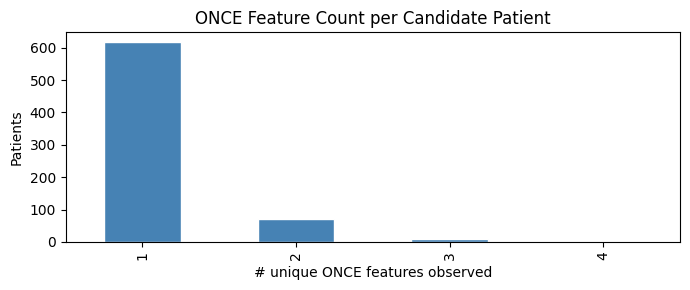

In [45]:
# ── Additional Step 4 sanity checks ─────────────────────────────────────────

# All candidate IDs must be a subset of sampled IDs — no phantom patients
assert candidate_ids.issubset(sampled_ids), (
    "candidate_ids contains patients not in sampled_ids — check filtering logic."
)
print("[OK] All candidate patients are within the sampled population.")

# ONCE feature overlap distribution: how many ONCE features does each candidate have?
# MAP uses co-features to produce a confident score; candidates with only 1 ONCE
# feature (just the anchor) can only score based on ICD count, not co-features.
candidate_obs = icd_obs[
    icd_obs["subject_id"].isin(candidate_ids)
    & icd_obs["event"].isin(once_features["codified_list"])
]
once_features_per_patient = candidate_obs.groupby("subject_id")["event"].nunique()

print("\n=== ONCE features per candidate (unique feature count) ===")
print(once_features_per_patient.describe().to_string())
print(
    f"\nCandidates with only 1 ONCE feature (anchor only): "
    f"{(once_features_per_patient == 1).sum():,}  "
    f"({100 * (once_features_per_patient == 1).mean():.1f}%)"
)
print(
    f"Candidates with ≥3 ONCE features: "
    f"{(once_features_per_patient >= 3).sum():,}  "
    f"({100 * (once_features_per_patient >= 3).mean():.1f}%)"
)

fig, ax = plt.subplots(figsize=(7, 3))
once_features_per_patient.value_counts().sort_index().plot.bar(
    ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("ONCE Feature Count per Candidate Patient")
ax.set_xlabel("# unique ONCE features observed")
ax.set_ylabel("Patients")
plt.tight_layout()
plt.show()

In [46]:
# Count total discharge notes available for candidate patients
if INCLUDE_NLP:
    total_available = 0
    for chunk in pd.read_csv(
        NOTES_FILE,
        usecols=["subject_id"],
        chunksize=10_000,
    ):
        total_available += chunk["subject_id"].isin(candidate_ids).sum()
    print(f"Notes available for candidates : {total_available:,}")
    print(f"Notes per patient cap          : {NOTES_PER_PATIENT} most recent")

Notes available for candidates : 2,213
Notes per patient cap          : 3 most recent


In [47]:
nlp_obs = pd.DataFrame(
    columns=["subject_id", "event_type", "event", "value", "datetime"]
)

if INCLUDE_NLP:
    from preprocessing import notes_to_events

    # Load all discharge notes for candidate patients
    note_chunks = []
    for chunk in pd.read_csv(
        NOTES_FILE,
        usecols=["subject_id", "text", "charttime"],
        parse_dates=["charttime"],
        chunksize=5_000,
    ):
        subset = chunk[chunk["subject_id"].isin(candidate_ids)].copy()
        if len(subset) > 0:
            note_chunks.append(subset)

    notes_df = pd.concat(note_chunks, ignore_index=True).dropna(subset=["text"])
    print(
        f"Notes loaded   : {len(notes_df):,} | {notes_df['subject_id'].nunique():,} patients"
    )
    print(f"Notes per patient cap : {NOTES_PER_PATIENT} most recent")

    print("\nRunning MedSpaCy NLP extraction...")

    nlp_obs = notes_to_events(
        notes_df,
        text_col="text",
        date_col="charttime",
        target_cuis=once_features["nlp_target_cuis"],
        max_note_chars=MAX_NOTE_CHARS,
        notes_per_patient=NOTES_PER_PATIENT,
    )

    print(
        f"NLP obs log    : {len(nlp_obs):,} CUI mentions | {nlp_obs['subject_id'].nunique():,} patients"
    )

    if len(nlp_obs) > 0:
        assert (nlp_obs["event_type"] == "cui").all()
        assert nlp_obs["event"].str.startswith("CUI:").all()
        assert nlp_obs["value"].isna().all()
        print("[OK] NLP obs schema check passed.")
        print(f"Unique CUIs found: {nlp_obs['event'].nunique()}")
        print("Top 5 CUIs by mention count:")
        print(nlp_obs["event"].value_counts().head())
    else:
        print(
            "[WARN] No CUI mentions extracted. Notes may not contain ONCE vocabulary terms."
        )
else:
    print("INCLUDE_NLP=False — NLP step skipped.")

Notes loaded   : 2,213 | 583 patients
Notes per patient cap : 3 most recent

Running MedSpaCy NLP extraction...


  MedSpaCy: 100%|██████████| 1226/1226 [01:37<00:00, 12.62note/s]

NLP obs log    : 16,572 CUI mentions | 583 patients
[OK] NLP obs schema check passed.
Unique CUIs found: 181
Top 5 CUIs by mention count:
event
CUI:C0030193    4061
CUI:C0013604     783
CUI:C0012634     673
CUI:C0003232     417
CUI:C1261287     414
Name: count, dtype: int64


## 6. Assemble Full Observation Log

Concatenate the ICD and NLP observation logs into a single DataFrame.

Alternatively, `build_obs_log()` does this in one call when starting from raw
tables — shown in the comment below for reference.

In [48]:
# Assemble from pre-built modality logs
obs_log = pd.concat([icd_obs, nlp_obs], ignore_index=True)

# ── Equivalent single-call alternative ──────────────────────────────────────
# from preprocessing import build_obs_log
# obs_log = build_obs_log(
#     icd_df       = diagnoses_with_dates,
#     icd_col      = "icd_code",
#     icd_date_col = "admittime",
#     notes_df       = notes_df,          # only if INCLUDE_NLP
#     notes_text_col = "text",
#     notes_date_col = "charttime",
#     target_cuis    = once_features["nlp_target_cuis"],
#     mapping_file   = PHECODE_MAP,
# )
# ────────────────────────────────────────────────────────────────────────────

print(
    f"Full obs_log : {len(obs_log):,} rows | {obs_log['subject_id'].nunique():,} patients"
)
print("\nRows by event_type:")
print(obs_log["event_type"].value_counts().to_string())
print(
    f"\nvalue column: {obs_log['value'].notna().sum()} non-null "
    f"(expected 0 — no lab events yet)"
)

# Sanity: every row must have the five standard columns
required = ["subject_id", "event_type", "event", "value", "datetime"]
assert all(c in obs_log.columns for c in required), (
    f"Missing columns: {set(required) - set(obs_log.columns)}"
)
assert obs_log["subject_id"].notna().all(), "subject_id must never be null"
assert obs_log["event"].notna().all(), "event must never be null"
assert obs_log["datetime"].notna().all(), "datetime must never be null"
print("\n[OK] obs_log schema check passed.")

print("\nSample rows:")
obs_log.sample(6, random_state=RANDOM_SEED)

Full obs_log : 334,902 rows | 12,240 patients

Rows by event_type:
event_type
phecode    318330
cui         16572

value column: 0 non-null (expected 0 — no lab events yet)

[OK] obs_log schema check passed.

Sample rows:


,subject_id,event_type,event,value,datetime
191044,16099779,phecode,PheCode:250.24,None,2148-05-31 14:14:00
185492,15949588,phecode,PheCode:585.1,None,2169-05-20 22:58:00
287188,19033304,phecode,PheCode:531.4,None,2151-01-12 17:38:00
260676,18276464,phecode,PheCode:276.41,None,2121-04-29 17:33:00
146481,14611411,phecode,PheCode:411.4,None,2140-05-16 00:14:00
267073,18480415,phecode,PheCode:572,None,2166-01-31 01:59:00


## 7. Preprocess for MAP

`preprocess_map` transforms the observation log into the two inputs required
by the MAP R algorithm:

- **`mat_df`** — wide patient × feature count matrix, restricted to ONCE features,
  with sparse features dropped (< `min_nonzero` non-zero patients)
- **`note_df`** — per-patient note count (Poisson exposure denominator); here
  derived from admission counts as a proxy (1 admission ≈ 1 discharge note)

In [49]:
from map import preprocess_map

mat_df, note_df = preprocess_map(
    obs_log=obs_log,
    admissions_df=admissions_df,
    once_features=once_features,
    main_phecode=MAIN_PHECODE,
)

print(f"mat_df  : {mat_df.shape}  (patients × features)")
print(f"note_df : {note_df.shape}")

# Sanity: anchor column must be first and must exist
anchor_col = f"PheCode:{MAIN_PHECODE}"
assert mat_df.columns[0] == anchor_col, f"First column should be anchor '{anchor_col}'"
assert (note_df["note_count"] >= 1).all(), (
    "note_count must be >= 1 (MAP Poisson requirement)"
)
assert mat_df.index.equals(note_df.index), (
    "mat_df and note_df must share the same patient index"
)
print("\n[OK] mat_df / note_df checks passed.")

print("\nFeature sparsity (non-zero patient count per feature):")
sparsity = (mat_df > 0).sum().sort_values()
print(sparsity.to_string())

print("\nnote_df stats:")
print(note_df["note_count"].describe().to_string())

mat_df  : (696, 76)  (patients × features)
note_df : (696, 1)

[OK] mat_df / note_df checks passed.

Feature sparsity (non-zero patient count per feature):
event
PheCode:726.3      20
CUI:C0020336       20
CUI:C3665472       20
CUI:C0042014       20
CUI:C1444656       21
CUI:C3841811       22
CUI:C1565489       23
CUI:C0021368       23
CUI:C3714614       23
PheCode:446.9      24
CUI:C0476273       26
CUI:C4035626       26
CUI:C0042384       27
PheCode:709.2      29
CUI:C0018802       31
CUI:C3854333       31
PheCode:696.42     32
CUI:C0011603       34
CUI:C4035627       35
CUI:C0032533       36
CUI:C3714660       37
CUI:C0043047       37
CUI:C0028778       38
CUI:C0003893       39
CUI:C0038317       41
CUI:C0029456       43
CUI:C0018801       44
CUI:C0231218       45
CUI:C0025677       46
CUI:C0205400       47
CUI:C0020564       47
CUI:C0023518       48
CUI:C0007642       49
CUI:C0332575       51
CUI:C0231221       52
CUI:C0028259       53
CUI:C0009676       54
CUI:C0700148       55
CU

## 8. Run MAP

`run_map` shells out to `map_runner.R` via `Rscript`. The R script renames
the anchor column to `"ICD"` (required by the MAP R package) and applies
`make.names()` to remaining columns for valid R identifiers.

Pass `main_icd_col = f"PheCode:{MAIN_PHECODE}"` — this must match the column
name in `mat_df` exactly.

In [50]:
from map import run_map

# MAP requires >= 2 features and >= 20 non-zero patients on the anchor
anchor_col = f"PheCode:{MAIN_PHECODE}"
n_anchor_nonzero = (mat_df[anchor_col] > 0).sum()
print(f"mat_df shape           : {mat_df.shape}")
print(f"Anchor non-zero count  : {n_anchor_nonzero}")

if mat_df.shape[1] < 2:
    print(
        "\n[SKIP] MAP requires at least 2 features. "
        "Try a larger SAMPLE_N or check ONCE features."
    )
elif n_anchor_nonzero < 20:
    print(
        f"\n[SKIP] Anchor has only {n_anchor_nonzero} non-zero patients; "
        "MAP needs >= 20. Try a larger SAMPLE_N."
    )
else:
    print("Running MAP (R subprocess)...")
    map_results = run_map(mat_df, note_df, main_icd_col=anchor_col)
    print(f"MAP finished. Output: {map_results.shape}")
    print("\nSample results:")
    display(map_results.head(8))

mat_df shape           : (696, 76)
Anchor non-zero count  : 208
Running MAP (R subprocess)...
MAP finished. Output: (696, 3)

Sample results:


,patient_id,score,phenotype
0,10021395,0.000000,0
1,10030412,0.000000,0
2,10071690,0.000000,0
3,10089779,0.000000,0
4,10138785,0.000000,0
5,10142675,0.387825,0
6,10161764,0.000000,0
7,10192480,0.000000,0


In [51]:
# ── Additional Step 7 sanity checks ─────────────────────────────────────────

# mat_df must contain no NaN values — MAP's R code has no NA handling
assert mat_df.isna().sum().sum() == 0, "mat_df contains NaN values — MAP will fail."
print("[OK] mat_df has no NaN values.")

# note_df must cover exactly the same patients as mat_df
assert set(note_df.index) == set(mat_df.index), (
    "mat_df and note_df patient sets diverge — MAP will produce mismatched results."
)
print("[OK] mat_df and note_df share identical patient sets.")

# MAP's Poisson model requires note_count >= 1; note_count=0 → -Inf log-likelihood
assert (note_df["note_count"] >= 1).all(), "note_count contains zeros — MAP will fail."
print(
    f"[OK] All note counts >= 1  (min={note_df['note_count'].min()}, max={note_df['note_count'].max()})."
)

# Co-feature prevalence in anchor+ vs anchor− patients.
# Every retained co-feature should be more common in anchor-positive patients —
# if a feature is more prevalent in anchor-negative patients it may add noise.
print("\n=== Co-feature prevalence: anchor+ vs anchor- patients ===")
has_anchor = mat_df[anchor_col] > 0
for col in mat_df.columns[1:]:
    prev_pos = (mat_df.loc[has_anchor, col] > 0).mean()
    prev_neg = (mat_df.loc[~has_anchor, col] > 0).mean()
    flag = "" if prev_pos >= prev_neg else "  ← [WARN] higher in anchor− patients"
    print(f"  {col:30s}  anchor+: {prev_pos:.1%}  anchor-: {prev_neg:.1%}{flag}")

# Row-sum distribution: very high counts can skew MAP's Poisson mixture model
row_sums = mat_df.sum(axis=1)
print("\n=== Total ONCE feature count per patient ===")
print(row_sums.describe().round(1).to_string())
p99 = row_sums.quantile(0.99)
high_burden = (row_sums > p99).sum()
print(f"Patients in top 1% burden (>{p99:.0f} total events): {high_burden:,}")

[OK] mat_df has no NaN values.
[OK] mat_df and note_df share identical patient sets.
[OK] All note counts >= 1  (min=1, max=70).

=== Co-feature prevalence: anchor+ vs anchor- patients ===
  CUI:C0000970                    anchor+: 21.2%  anchor-: 28.3%  ← [WARN] higher in anchor− patients
  CUI:C0002871                    anchor+: 20.7%  anchor-: 19.1%
  CUI:C0003232                    anchor+: 26.0%  anchor-: 34.4%  ← [WARN] higher in anchor− patients
  CUI:C0003864                    anchor+: 15.9%  anchor-: 25.0%  ← [WARN] higher in anchor− patients
  CUI:C0003873                    anchor+: 46.6%  anchor-: 0.2%
  CUI:C0003893                    anchor+: 2.9%  anchor-: 6.8%  ← [WARN] higher in anchor− patients
  CUI:C0004096                    anchor+: 10.6%  anchor-: 12.7%  ← [WARN] higher in anchor− patients
  CUI:C0005437                    anchor+: 10.6%  anchor-: 11.7%  ← [WARN] higher in anchor− patients
  CUI:C0005558                    anchor+: 13.5%  anchor-: 15.0%  ← [WAR

## 9. Sanity Checks on MAP Output

Three checks to validate the phenotyping result:

1. **Score distribution** — should be right-skewed (most patients near 0, cases at higher values)
2. **Case / control counts** — expected RA prevalence in this population is ~20–30%
   (because the study population is pre-filtered to patients with ≥1 ONCE feature)
3. **ICD burden check** — MAP cases must have higher raw PheCode 714.1 counts than
   controls; ideally 100% of cases have ≥1 RA ICD code

In [52]:
# ── Additional Step 8 sanity checks ─────────────────────────────────────────
try:
    map_results
except NameError:
    print("MAP did not run — skipping.")
else:
    # MAP must return a row for every patient in mat_df
    map_pts = set(map_results["patient_id"])
    mat_pts = set(mat_df.index)
    missing = mat_pts - map_pts
    extra = map_pts - mat_pts
    assert not missing, f"{len(missing):,} mat_df patients missing from MAP results."
    assert not extra, f"{len(extra):,} MAP result patients not in mat_df."
    print(
        f"[OK] MAP results cover all {len(mat_pts):,} mat_df patients (no missing, no extra)."
    )

    # Scores must be in [0, 1] — MAP posterior probabilities
    assert map_results["score"].between(0, 1).all(), (
        f"MAP scores outside [0,1]: min={map_results['score'].min():.4f}, max={map_results['score'].max():.4f}"
    )
    print(
        f"[OK] All scores in [0, 1]  "
        f"(min={map_results['score'].min():.4f}, max={map_results['score'].max():.4f})."
    )

    # Phenotype must be binary 0/1
    assert set(map_results["phenotype"].unique()).issubset({0, 1}), (
        f"Unexpected phenotype values: {map_results['phenotype'].unique()}"
    )
    print("[OK] Phenotype labels are binary 0/1.")

    # Score bimodality: MAP posteriors should cluster near 0 and near 1.
    # A flat or unimodal distribution means MAP converged poorly —
    # typically from too few features or too few anchor-positive patients.
    low = (map_results["score"] < 0.1).mean()
    high = (map_results["score"] > 0.9).mean()
    mid = 1 - low - high
    print("\n=== Score bimodality check ===")
    print(f"  score < 0.1 (clear controls): {low:.1%}")
    print(f"  score > 0.9 (clear cases):    {high:.1%}")
    print(f"  score 0.1–0.9 (uncertain):    {mid:.1%}")
    if mid > 0.30:
        print(
            "  [WARN] >30% uncertain scores — MAP may need more features or a larger sample."
        )
    else:
        print("  [OK] Score distribution is reasonably bimodal.")

    # Co-feature enrichment in MAP cases vs controls
    scored = map_results.set_index("patient_id")
    cases_idx = scored[scored["phenotype"] == 1].index
    controls_idx = scored[scored["phenotype"] == 0].index
    print("\n=== Co-feature prevalence: MAP cases vs controls ===")
    for col in mat_df.columns[1:]:
        prev_case = (mat_df.loc[mat_df.index.isin(cases_idx), col] > 0).mean()
        prev_ctrl = (mat_df.loc[mat_df.index.isin(controls_idx), col] > 0).mean()
        flag = "" if prev_case >= prev_ctrl else "  ← [WARN] higher in controls"
        print(f"  {col:30s}  cases: {prev_case:.1%}  controls: {prev_ctrl:.1%}{flag}")

[OK] MAP results cover all 696 mat_df patients (no missing, no extra).
[OK] All scores in [0, 1]  (min=0.0000, max=0.6833).
[OK] Phenotype labels are binary 0/1.

=== Score bimodality check ===
  score < 0.1 (clear controls): 70.1%
  score > 0.9 (clear cases):    0.0%
  score 0.1–0.9 (uncertain):    29.9%
  [OK] Score distribution is reasonably bimodal.

=== Co-feature prevalence: MAP cases vs controls ===
  CUI:C0000970                    cases: 30.8%  controls: 25.5%
  CUI:C0002871                    cases: 29.7%  controls: 18.0%
  CUI:C0003232                    cases: 38.5%  controls: 30.9%
  CUI:C0003864                    cases: 26.4%  controls: 21.7%
  CUI:C0003873                    cases: 65.9%  controls: 6.3%
  CUI:C0003893                    cases: 5.5%  controls: 5.6%  ← [WARN] higher in controls
  CUI:C0004096                    cases: 9.9%  controls: 12.4%  ← [WARN] higher in controls
  CUI:C0005437                    cases: 16.5%  controls: 10.6%
  CUI:C0005558          

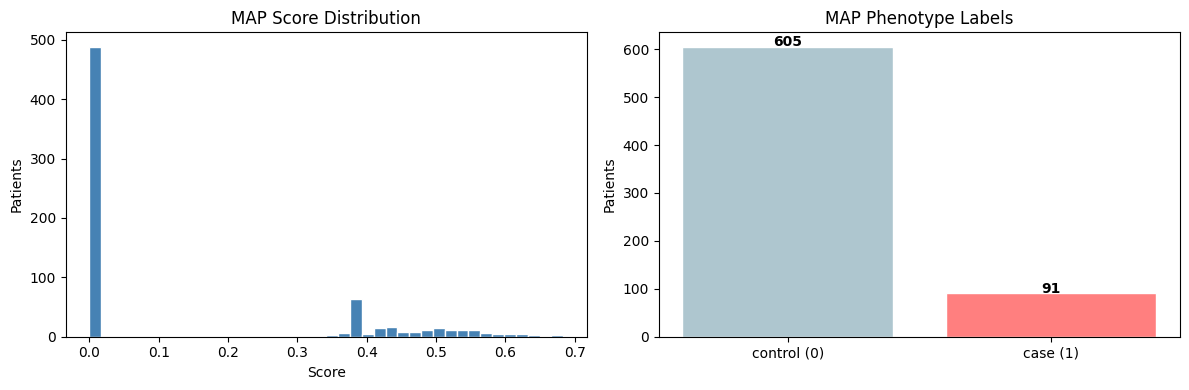

count    696.000000
mean       0.138178
std        0.216219
min        0.000000
25%        0.000000
50%        0.000000
75%        0.387825
max        0.683266


In [53]:
try:
    map_results
except NameError:
    print("MAP did not run (see skip message above). Skipping validation.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(map_results["score"], bins=40, color="steelblue", edgecolor="white")
    axes[0].set_title("MAP Score Distribution")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Patients")

    counts = map_results["phenotype"].value_counts().sort_index()
    axes[1].bar(
        ["control (0)", "case (1)"],
        counts.values,
        color=["#aec6cf", "#ff7f7f"],
        edgecolor="white",
    )
    for i, v in enumerate(counts.values):
        axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")
    axes[1].set_title("MAP Phenotype Labels")
    axes[1].set_ylabel("Patients")

    plt.tight_layout()
    plt.show()

    print(map_results["score"].describe().to_string())

In [54]:
try:
    map_results
except NameError:
    pass
else:
    scored = map_results.set_index("patient_id")
    cases = scored[scored["phenotype"] == 1].index
    controls = scored[scored["phenotype"] == 0].index

    ra_counts = mat_df[anchor_col].rename("ra_phecode_count")
    case_ra = ra_counts.reindex(cases).fillna(0)
    ctrl_ra = ra_counts.reindex(controls).fillna(0)

    pct_cases_with_icd = (case_ra > 0).mean() * 100
    pct_ctrl_with_icd = (ctrl_ra > 0).mean() * 100

    print(f"=== Sanity check: PheCode {MAIN_PHECODE} burden ===")
    print(
        f"  Cases    n={len(cases):,}  mean={case_ra.mean():.2f}  median={case_ra.median():.0f}  "
        f"≥1 ICD: {pct_cases_with_icd:.1f}%"
    )
    print(
        f"  Controls n={len(controls):,}  mean={ctrl_ra.mean():.2f}  median={ctrl_ra.median():.0f}  "
        f"≥1 ICD: {pct_ctrl_with_icd:.1f}%"
    )

    assert pct_cases_with_icd > pct_ctrl_with_icd, (
        "MAP cases should have more RA ICD codes than controls."
    )
    print("[OK] Cases have higher PheCode 714.1 burden than controls.")

    print("\n=== Final cohort summary ===")
    n_cases = len(cases)
    n_total = len(scored)
    print(f"  Study population : {n_total:,} patients")
    print(f"  MAP cases        : {n_cases:,} ({100 * n_cases / n_total:.1f}%)")
    print(f"  MAP controls     : {n_total - n_cases:,}")
    print(f"  Features used    : {mat_df.shape[1]} ({anchor_col} + co-features)")
    print(f"  NLP included     : {INCLUDE_NLP}")

    print("\nTop 10 cases by MAP score:")
    top = (
        scored[["score", "phenotype"]]
        .join(mat_df[[anchor_col]].rename(columns={anchor_col: "ra_icd_count"}))
        .join(note_df.rename(columns={"note_count": "admissions"}))
        .sort_values("score", ascending=False)
        .head(10)
    )
    display(top)

=== Sanity check: PheCode 714.1 burden ===
  Cases    n=91  mean=3.33  median=2  ≥1 ICD: 100.0%
  Controls n=605  mean=0.29  median=0  ≥1 ICD: 19.3%
[OK] Cases have higher PheCode 714.1 burden than controls.

=== Final cohort summary ===
  Study population : 696 patients
  MAP cases        : 91 (13.1%)
  MAP controls     : 605
  Features used    : 76 (PheCode:714.1 + co-features)
  NLP included     : True

Top 10 cases by MAP score:


,score,phenotype,ra_icd_count,admissions
patient_id,,,,
15999409,0.683266,1,1,5
15851040,0.676311,1,5,5
16038691,0.670295,1,3,3
18123331,0.640925,1,5,5
16246823,0.634162,1,3,3
11533366,0.633090,1,28,34
13104650,0.631617,1,7,7
17689611,0.627679,1,1,3
12563517,0.622489,1,2,2
